# Learning Rate Schedulers

- Adjusts LR during training
- Often improves convergences and accuracy

1. StepLR
2. MultiStepLR
3. ConstantLR
4. LinearLR
5. ExponentialLR
6. PolynomialLR
7. CosineAnnealingLR
8. ChainedScheduler
9. SequentialLR
10. ReduceLROnPlateau

In [514]:
# import
import torch
import matplotlib.pyplot as plt
import numpy as np

In [515]:
# Fixtures
LR = 1.0
EPOCHS = 10

In [516]:
# Matplotlib
def plot_lr(all_lrs):
    plt.plot(all_lrs)
    plt.xlabel("Iter →")
    plt.ylabel("LR →")
    plt.grid(True)
    plt.xticks(np.arange(0, EPOCHS, 1))
    plt.yticks(np.arange(0, LR+0.1, 0.1))
    plt.show()

In [517]:
# Optimizer
def build_optimizer(lr):
    dummy_param = torch.nn.Parameter(torch.zeros(1))
    return torch.optim.AdamW([dummy_param], lr=lr)


In [518]:
# run 
def run_iter(epochs, optim, scheduler):
    all_lrs = []
    for _ in range(epochs):
        all_lrs.append(scheduler.get_last_lr())
        optim.step()
        scheduler.step()
    return all_lrs

In [519]:
# Step Scheduler
from torch.optim.lr_scheduler import StepLR
def step_scheduler():
    optim = build_optimizer(lr=LR)
    step_scheduler = StepLR(optim, step_size=1, gamma=0.5, last_epoch=-1)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=step_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# step_scheduler()

In [520]:
# MultiStepLR Scheduler
from torch.optim.lr_scheduler import MultiStepLR
def multistep_scheduler():
    optim = build_optimizer(lr=LR)
    mulitstep_scheduler = MultiStepLR(optim, milestones=[4,6], gamma=0.5, last_epoch=-1)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=mulitstep_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# multistep_scheduler()

In [521]:
# ConstantLR Scheduler
from torch.optim.lr_scheduler import ConstantLR
def constant_scheduler():
    optim = build_optimizer(lr=LR)
    constant_scheduler = ConstantLR(optim, factor=0.5, total_iters=8, last_epoch=-1)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=constant_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# constant_scheduler()

In [522]:
# LinearLR Scheduler
from torch.optim.lr_scheduler import LinearLR
def linear_scheduler():
    optim = build_optimizer(lr=LR)
    linear_scheduler = LinearLR(optim, start_factor=LR, end_factor=0.5, total_iters=EPOCHS, last_epoch=-1)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=linear_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# linear_scheduler()

In [523]:
# ExponentialLR Scheduler
from torch.optim.lr_scheduler import ExponentialLR
def exp_scheduler():
    optim = build_optimizer(lr=LR)
    exp_scheduler = ExponentialLR(optim, gamma=0.5, last_epoch=-1)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=exp_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# exp_scheduler()

In [524]:
# PolynomialLR Scheduler
from torch.optim.lr_scheduler import PolynomialLR
def poly_scheduler():
    optim = build_optimizer(lr=LR)
    poly_scheduler = PolynomialLR(optim, total_iters=5, power=1, last_epoch=-1)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=poly_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# poly_scheduler()

In [525]:
# CosineAnnealingLR Scheduler
from torch.optim.lr_scheduler import CosineAnnealingLR
def cosine_annealing_scheduler():
    optim = build_optimizer(lr=LR)
    cosine_annealing_scheduler = CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=0, last_epoch=-1)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=cosine_annealing_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# cosine_annealing_scheduler()

In [526]:
# ChainedScheduler Scheduler
from torch.optim.lr_scheduler import ChainedScheduler, ConstantLR, ExponentialLR
def chained_scheduler():
    optim = build_optimizer(lr=LR)
    scheduler1 = ConstantLR(optim, factor=0.5, total_iters=8, last_epoch=-1)
    scheduler2 = ExponentialLR(optim, gamma=0.5, last_epoch=-1)
    chained_scheduler = ChainedScheduler([scheduler1, scheduler2], optimizer=None)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=chained_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# chained_scheduler()

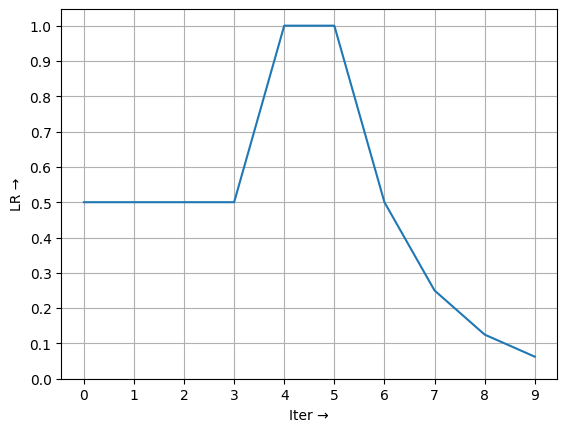

[[0.5], [0.5], [0.5], [0.5], [1.0], [1.0], [0.5], [0.25], [0.125], [0.0625]]


In [ ]:
# SequentialLR Scheduler
from torch.optim.lr_scheduler import SequentialLR
def sequential_scheduler():
    optim = build_optimizer(lr=LR)
    scheduler1 = ConstantLR(optim, factor=0.5, total_iters=4, last_epoch=-1)
    scheduler2 = ExponentialLR(optim, gamma=0.5, last_epoch=-1)
    sequential_scheduler = SequentialLR(optim, schedulers=[scheduler1, scheduler2], milestones=[5], last_epoch=-1)

    all_lrs = run_iter(epochs=EPOCHS, optim=optim, scheduler=sequential_scheduler)
    plot_lr(all_lrs)
    print(all_lrs)

# sequential_scheduler()